## `Filtre bilatéral`

- Le filtre bilatéral est **non linéaire** il lisse tout en préservant les bords, mais son calcul exact est très coûteux. 

- Le filtre est décrit comme une convolution gaussienne dans un espace $S×R$ de dimension supérieure (position + intensité), suivie d’un “slicing” et d’une division (coordonnées homogènes). 

- Cette convolution est un passe‑bas, qui se calcule sur une grille $S×R$ fortement sous échantillonnée en espace et intensité, avec un contrôle d’erreur en termes de bande passante et de pas d’échantillonnage. 

- `Le cœur de l’algorithme` : 
  - construire $(w, wi)$ sur $S×R$, 
  - filtrer à l'aide d'une gaussienne 3D (via FFT ou noyau tronqué et séparable), 
  - échantillonner le volume filtré au point $(p, I(p))$ 
  - puis normaliser. 

- Pour un même temps de calcul, cette méthode est plus précise que les approximations antérieures (Durand–Dorsey piecewise‑linear, séparabilité 1D, box itéré), surtout pour de grands noyaux spatiaux. 

- Ils montrent des temps de l’ordre de la seconde pour des images 2 Mpx avec un résultat visuellement proche de l’évaluation exacte qui prend plusieurs dizaines de minutes, et l’extension est naturelle aux images couleur et au cross‑bilateral.

- Très efficace pour de nombreuses tâches en vision par ordinateur et infographie. 
- Son calcul exact est coûteux, avec des méthodes d’accélération dont la précision reste mal connue. 

In [2]:
import sys, os
import numpy as np
toolbox_parent = r"/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_IMGCMPT/TP23_Imagerie_Computationnelle"
sys.path.insert(0, toolbox_parent)

from nt_toolbox.general import *
from nt_toolbox.signal import *
import nt_toolbox as nt

%matplotlib inline
%load_ext autoreload
%autoreload 2

`Filtrage linéaire Gaussien`.  
L’opération de filtrage la plus élémentaire est gaussien, qui a tendance à adoucir ou flouter les contours.

In [3]:
# Image size.
n = 256*2

Chargement de l'image

(512, 512)


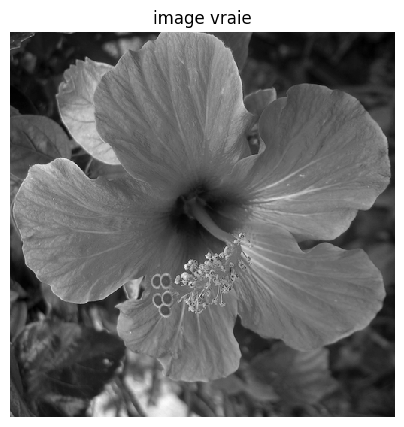

In [4]:
path= '/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_IMGCMPT/TP23_Imagerie_Computationnelle/'
name = path + 'nt_toolbox/data/hibiscus.bmp'
f0 = load_image(name, n)          # f0.shape = (512, 512)
f0 = (f0 - f0.min()) / (f0.max() - f0.min() + 1e-12)
print(f0.shape)
from skimage.transform import rescale
f0_small = rescale(f0, scale=0.5, anti_aliasing=True)   # par ex. moitié moins grand
plt.figure(figsize=(5, 5))
imageplot(clamp(f0),'image vraie')

Le flou est la manière la plus simple de lisser une image, la convolution Gaussienne de variance $\sigma$ est donnée par : 
- $G_{\sigma}(x)$ dénote du kernel Gaussian 2D : $ G_\sigma(x) = \Large \frac{1}{2\pi\sigma^2} e^{- \Large \frac{||{x}||^2}{2\sigma^2}}$

- $\large GC_{\sigma}(f)(x) = \sum_{y \in S}  G_\sigma(||x-y||) f(y)$
  - $(||x - y||)$ représente la distance Euclidienne.
  - $f(y)$ pour l'image au pixel $y$.  
  - le poids du pixel $x$ est défini par la gaussienne $G_{\sigma}(x - y)$, 
  - l’ensemble $S$ de toutes les positions possibles de l’image appellé le domaine spatial.
  - où $\sigma$ est un paramètre qui définit la taille du voisinage. 
  - l'influence d'un pixel sur un autre ne dépend que de leur distance dans l'image.

Le coût en opérations d’une convolution dépend de la façon dont on la calcule. 

`Domaine spatial` : 
- pour une image de $N$ pixels et un noyau gaussien de largeur caractéristique $\sigma_x$, 
- le noyau a une taille effective proportionnelle à $\sigma_x^2$ en 2D.
- donc la convolution directe a une complexité $O(N\sigma_x^2$) : 
- pour chaque pixel, on fait une somme sur tous les coefficients du noyau.

`Domaine de Fourier` : 
- on utilise le théorème de convolution : 
- la convolution dans l’espace = produit point à point dans le domaine de Fourier.
- se fait en 3 FFT (signal, noyau, inverse) chacune en une complexité $O(NlogN)$ et totale .

__`Conséquence pratique :`__
- pour des petits noyaux $(3×3,5×5)$, la méthode spatiale est plus rapide (car $\sigma_x^2$ est petit).
- pour des noyaux très larges (flous gaussiens très lissés, filtres longue portée), 
- le coût $O(N\sigma_x^2)$ devient énorme et la méthode par FFT $O(NlogN)$ devient avantageuse.
- pour simplifier considérons le domaine de Fourier (implique des conditions aux bords périodiques).
- définissons une gaussienne centrée dans le coin supérieur gauche, correspondant au point d’indice nul pour la FFT.

In [38]:
#H, W = f0.shape
#X,Y : grilles 2D centrées au coin (0,0)
#X, Y = np.meshgrid(np.arange(W), np.arange(H))
#GaussianFilter = lambda s: np.exp(-(X**2 + Y**2) / (2 * s**2))

- tx est construit pour représenter les fréquences 2D associées à une FFT discrète de taille n (512). 
- tx n’est pas trié « de -n/2 à n/2 » car, 
  - il suit l’ordre d’indexation de la FFT (positif d’abord, puis négatif), 
  - ceci permet à ce que X et Y soient alignés avec les coefficients de la FFT de l'image.
- Si nous préfèrerions voir une grille centrée (de −n/2 à n/2−1 dans l’ordre croissant),
  - on utiliserait plutôt np.fft.fftshift, 
  - mais là on se cale sur l’ordre brut de la FFT.

In [5]:
H, W = f0.shape
tx = np.concatenate((np.arange(0,n/2), np.arange(-n/2,0)))
[Y,X] = np.meshgrid(tx, tx)
GaussianFilter = lambda s: np.exp(-(X**2 + Y**2) / (2 * s**2))

Afficher un exemple Gaussien recentré

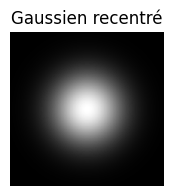

In [6]:
plt.figure(figsize=(2,2))
imageplot(np.fft.fftshift(GaussianFilter(80)),'Gaussien recentré')

- Définir un raccourci pour effectuer un filtrage gaussien linéaire dans le domaine de Fourier. 
- Cette fonction est capable de traiter en parallèle un bloque 3D $F$ filtrant chaque tranche $|F(:,:,i)|$. 

In [8]:
Filter = lambda F, s: np.real(np.fft.ifft2(np.fft.fft2(F) * np.fft.fft2(GaussianFilter(s))))

Exemple de fitrage $G_g{\sigma}(f_0) $.

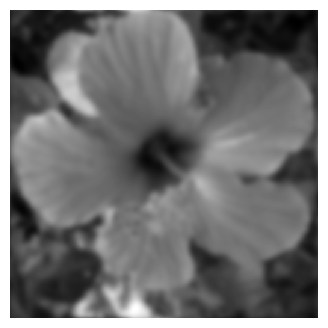

In [9]:
plt.figure(figsize=(4,4))
imageplot(Filter(f0,5))

### __`Exercice 1`__
Afficher le filtrage Gaussien de convolution $Gg_{\sigma}(f_0)$ avec une augmentation de la taille $\sigma$.

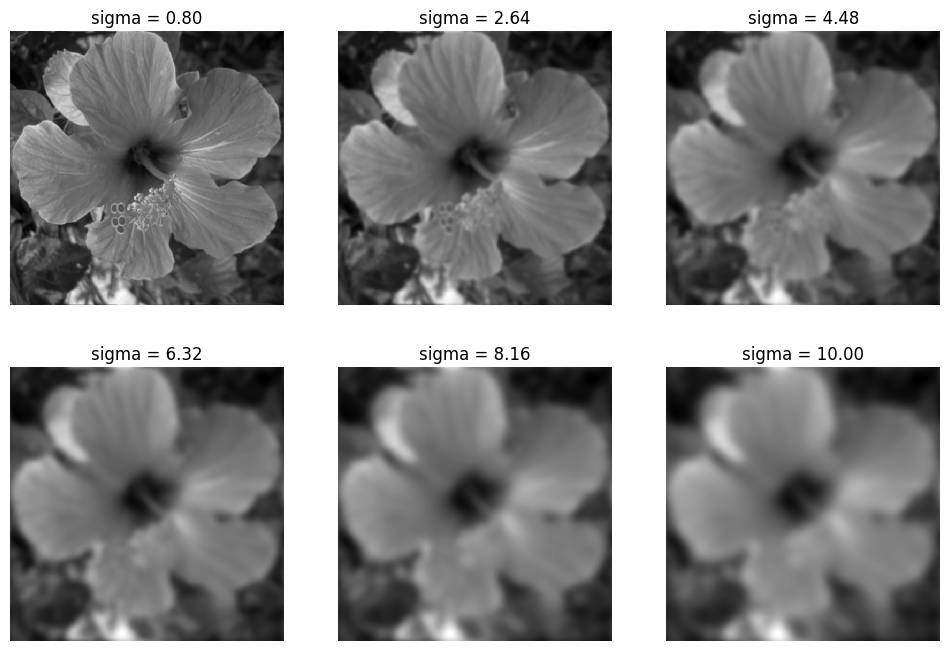

In [10]:
import matplotlib.pyplot as plt
import numpy as np

sig_list = np.linspace(.8,10,6)
ncols = 3
nimgs = len(sig_list)
nrows = int(np.ceil(nimgs / ncols))

plt.figure(figsize=(12,8))

for i, sig in enumerate(sig_list):
    imageplot(Filter(f0,sig),f"sigma = {sig:.2f}", [nrows, ncols, i+1])
plt.show()

### `Filtre bilatéral`
Le filtre bilatéral possède plusieurs qualités qui expliquent son succès :
 - L’idée essentielle du **filtre** bilatéral est que, pour qu’un pixel puisse en influencer un autre, il doit non seulement se trouver à proximité spatiale, mais aussi avoir une valeur similaire. 

 - Chaque pixel est remplacé par une moyenne de ses voisins, cet aspect est important car il facilite l’intuition sur son comportement, son adaptation à des besoins spécifiques, ainsi que sa mise en œuvre.

 `Dépend de 2 paramètres qui indiquent la taille et le contraste des structures à préserver`.
 - Il peut être utilisé de manière non itérative rendant le réglage des paramètres plus simple, puisque leur effet ne s’accumule pas au fil de plusieurs itérations.

 - Il peut être calculé à une vitesse pratiquement instantané, même sur de grandes images, grâce à des schémas numériques efficaces et même en temps réel si du matériel graphique de type GPU est disponible.

 - Le filtre bilatéral est **spatialement** variant qui préserve mieux les contours que le filtre gaussien classique, 
 - il est controllé par deux paramètres:  
   - une largeur spatiale $\large \sigma_x$ lorsqu'elle augmente, le filtre converge vers une convolution gaussienne, 
   - une largeur d'intensité $\large \sigma_v$ qui permet de lisser des structures de plus grande taille. 
$$\large \mathcal{B}_{\sigma_x,\sigma_v}(f)(x) = \frac{1}{Z_x} \sum_y G_{\sigma_x}(x-y)\, G_{\sigma_v}(f(x)-f(y))\, f(y)$$
`1°) L’image d’entrée` $f$ `à la position` $x$ : 
C'est une fonction image, qui à chaque pixel $x$ associe une intensité $f(x)$ (en niveaux de gris .i.e) 
- $x$ : position du pixel central que l’on filtre (un vecteur 2D en pratique, type $(i,j)$). 
- $y$ : parcourt les pixels du voisinage de $x$ (typiquement dans une fenêtre $(2k+1)×(2k+1)$).
  - but : produire une image $B_{σx,σv}(f)$ où $x$ est un lissage des $f(y)$ autour de $x$, préservant les contours.
`2°) Le noyau spatial` $G_{\sigma_x} (x−y)$ `et` ${\sigma}x$
C’est un poids qui ne dépend que de la distance géométrique entre $x$ et $y$.
- typiquement $G_\sigma(x - y) = \Large e^{- \Large \frac{||{x - y}||^2}{2\sigma^2}}$
- rôle pondérer les pixels $y$ fonction de leur distance à $x$, plus $y$ est loin de $x$ plus son poids diminue.
- $\sigma_x$ (souvent noté $\sigma_s$ ) le paramètre spatial.
  - petit $\sigma_x$ on ne prend en compte que les voisins très proches, donc lissage très local.
  - grand $\sigma_x$ on considère un voisinage plus large, donc lissage de structures de grande taille 
`3°) Le noyau de gamme photométrique, ou en intensité)` $G_{\sigma_v}(f(x)-f(y)) \text{ et } \sigma_v $
C’est un poids qui dépend de la différence d’intensité entre le pixel central $x$ et le pixel voisin $y$
- $G_{\sigma_v}(f(x)-f(y))$ gaussienne dite de gamme (ou photométrique, ou en intensité).
- Typiquement : $G_{\sigma_v}(f(x)-f(y)) = \exp({- \Large \frac{({f(x) - f(y)})^2}{2\sigma^2}})$
- rôle pondérer les pixels $y$ selon la différence d’intensité entre $f(x)$ et $f(y)$
  - si $f(y)$ est proche de $f(x)$, le poids est proche de 1.
  - si f(y) est très différent de $f(x)$, le poids devient très faible.
- $\sigma_v$ (souvent noté $\sigma_r$) : paramètre de gamme / radiométrique.
  - petit $\sigma_v$ : on ne moyenne qu’avec des pixels de valeur proche de $f(x)$ → on évite de mélanger des régions séparées par un contour, donc on préserve mieux les bords.

  - grand $\sigma_v$ : la gaussienne de gamme devient plus plate, donc presque constante sur l’intervalle de valeurs de l’image ; le filtre se rapproche alors d’un flou gaussien classique (pondération surtout spatiale). 
`4°) Le terme f(y)`  
$f$ l'image d’entrée, $f(y)$ est l’intensité (ou vecteur couleur) du pixel situé en position $y$.
- Le filtre remplace la valeur $f(x)$ par une moyenne pondérée des $f(y)$ dans le voisinage, 
- où le poids est le produit des deux noyaux : $\omega(x,y)= G_{\sigma_x}(x-y)\, G_{\sigma_v}(f(x)-f(y))$
- c’est le poids associé au pixel $y$ quand on filtre le pixel $x$.
Autrement dit :
 - les gaussiennes donnent les poids,
 - $f(y)$ est ce qu’on moyenne avec ces poids.
`5°) La normalisation` $Z_x$
$$\large Z_x = \sum_y G_{\sigma_x}(x-y)\, G_{\sigma_v}(f(x)-f(y))$$
  - $Z_x$ : terme de normalisation qui assure que la somme des poids vaut 1 au point $x$.
  - concrètement, $\frac{1}{Z_x}$ garantit que $B_{\sigma_v,\sigma_v} (f)(x)$ est une moyenne pondérée des $f(y)$ du voisinage.
  - sans $Z_x$, l’amplitude peut varier d’un pixel à l’autre fonction du nombre, de la “force” des voisins compatibles.
`6°) Interprétation globale`
 - Pour un pixel $x$, chaque voisin $y$ contribue à la valeur filtrée avec un poids.
$$\omega(x,y) = G_{\sigma_x}(x-y)\, G_{\sigma_v}(f(x)-f(y)) $$
- le poids est grand si : 
   - $y$ est proche de $x$ dans l’espace (même région), 
   - et si $f(y)$ est proche de $f(x)$ en intensité (même “région photométrique”).
- il est petit si le voisin est loin ou de valeur très différente (de l’autre côté d’un bord par exemple).
Ainsi, le filtre lisse le bruit à l’intérieur des régions homogènes, mais évite de mélanger des régions séparées par un contour marqué.

### `Filtre bilatéral par empilement`

Une implémentation directe du filtre bilatéral dans le domaine spatial nécessite $O(N \sigma_x^2)$ opérations, où 
 - $N$ est le nombre de pixels exploite le fait que, 
   - $\large \forall$  pixels $x$ ayant la même valeur $v = f(x)$, 
   - le filtre bilatéral peut s’écrire comme un ratio de convolutions :$\Large \frac{\big[ G_{\sigma_x} * (f \cdot W_v) \big](x)}{\big[ G_{\sigma_x} \star W_v \big](x)}$
   - où la carte de poids est $W_v(x) = G_{\sigma_v}(v - f(x))$ 
 - Au lieu de calculer toutes les cartes de poids $W_v$ pour toutes les valeurs de pixels possibles $v$, 
 - On considère un sous‑ensemble $\{v_i\}_{i=1}^p$ de $p$ valeurs et on calcule les poids $\{W_{v_i}\}_i$.
 - À partir des convolutions, on obtient les cartes $\{F_{v_i}\}_i$, combinées pour fournir une approximation de $\mathcal{B}_{\sigma_x,\sigma_v}(f)$. 
 - Le temps de calcul est de $O(p\,N\log N)$ dans le domaine de Fourier et de $O(p\,N\sigma_x^2)$ dans le domaine spatial. 

### `Filtre bilatéral par empilement`
Une implémentation directe du filtre bilatéral dans le domaine spatial nécessite $O(N \sigma_x^2)$ opérations, où $N$ est le nombre de pixels de l’image. 
Pour accélérer le calcul, on exploite le fait que, pour tout ensemble de pixels $x$ de valeur identique $v = f(x)$, le filtre bilatéral peut s’écrire comme un ratio de convolutions :
$\mathcal{B}_{\sigma_x,\sigma_v}(f)(x)= \frac{\big[ G_{\sigma_x} * (f \cdot W_v) \big](x)}{\big[ G_{\sigma_x} * W_v \big](x)}$ où la carte de poids associée à la valeur $v$ est définie par $\omega_v(x) = G_{\sigma_v}(v - f(x)).$ 
#### __`Que signifie v=f(x)`__
Dans cette méthode « par empilement », on distingue deux choses :
- $x$ qui est la position du pixel.
- $f(x)$ qui est la valeur en intensité de ce pixel.
On choisit une valeur de référence $v$ dans le domaine des intensités
- lorsque l'on choisit un maillage ${v_i}$, chaque $v_i$ sert à définir une carte de poids 
- on crée un ensemble de valeurs scalaires (niveaux de gris) dans [0,1], i.e. np.linspace(0,1,p), 
- pour une valeur d’un maillage $\{v_i\}$, sur tous les pixels $x$ ayant la même valeur $v=f(x)$
- on se place sur le niveau de gris $v$, et on regarde les pixels qui ont cette valeur.
- pour $v$ on construit une carte de poids $\omega_v$ sur toutes les positions $x$ de l’image : $\omega_v(x) = G_{\sigma_v}(v - f(x))$
Au lieu de calculer les cartes de poids $\omega_v$ pour toutes les valeurs de pixels possibles $v$, on  considère un sous‑ensemble $\{v_i\}_{i=1}^p$ de $p$ valeurs échantillonnées dans le domaine photométrique et on calcule seulement les cartes $\{W_{v_i}\}_i$.
À partir des convolutions correspondantes, on obtient les cartes $\{F_{v_i}\}_i$, qui sont ensuite combinées pour fournir une approximation de $\mathcal{B}_{\sigma_x,\sigma_v}(f)$. Le temps de calcul est alors de $O(p\,N\log N)$ si les convolutions sont effectuées dans le domaine de Fourier, et de $O(p\,N\sigma_x^2)$ dans le domaine spatial.

La fonction ci-dessous crée un stack de cartes de poids  $W_{v_i}$ de taille $(n, n, p)$.

In [ ]:
print(f"f0.shape : {f0.shape}, f0[:,:,None].shape : {f0[:,:,None].shape}")
x = np.array([[[1,2]]]) 
print(f"x.shape : {x.shape}")
x = np.repeat(f0[:,:,None], 2, axis=2)
print(f"x.shape : {x.shape} \n{x[0].shape}")
x = np.repeat(x, 2, axis=2)
print(f"x.shape : {x.shape} \n{x[0].shape}")

f0.shape : (512, 512), f0[:,:,None].shape : (512, 512, 1)
x.shape : (1, 1, 2)
x.shape : (512, 512, 2) 
(512, 2)


In [ ]:
vi = np.linspace(0,1,10)
vi = vi.reshape(1,1,10)
#print(f"vi.shape : {vi.shape} \n {vi}") 
vi = np.repeat(vi, 10, axis=2)
#print(f"f0_rep.shape : {vi.shape} \n {vi}")

 :::
_`Construire le poids d'une couche`_ $ \{ W_{v_i} \}_i $ pour $v_i$ uniformément distribué entre $[0,1]$
_`Définir la carte de poids`_ $W_{v_i}(x) = G_{\sigma_v} (v_i −f(x))$.
 :::
 :::
__1. Rappel de la définition__
- On veut, $\forall v_i \in [0,1]$, 
- définir la carte de poids $W_{v_i}(x) = G_{\sigma_v} (v_i −f(x))$,
  - où $G{\sigma_v}$ est la gaussienne en intensité (paramètre $\sigma_v$ ), 
  - et $f(x)$ l’image normalisée dans $[0,1]$.
- On regroupe ensuite toutes ces cartes dans un tenseur 3D W de taille $(n,n,p)$ 
- si l’image fait $n×n$ et qu’on prend p valeurs $v_i$ alors $W[:,:,i]$ correspond à $W_{v_i}$
:::   

In [27]:
# le noyau gaussien 1D appliqué point par point.
gaussian = lambda x, sigma: np.exp(-x**2 / (2*sigma**2))

def WeightMap(f0, sv, p):
    n, m = f0.shape
    assert n == m
    # contient toutes les valeurs v_i uniformemément sur [0,1]
    vi = np.linspace(0,1,p)              
    vi = vi.reshape(1, 1, p)                        # [1, 1, p]
    # construit une stack 3D pour chaque i entre 0 et p-1, f0_rep est une copie de l’image f0.                                               
    f0_rep = np.repeat(f0[:, :, None], p, axis=2)  # [n, n, p]
    # sert à fabriquer un tenseur (n,n,p) à partir d’un vecteur v de taille (1,1,p). 
    v_rep  = np.repeat(np.repeat(vi, n, axis=0), n, axis=1)  # [n, n, p]
    return gaussian((v_rep - f0_rep), sv)

Calculer le poids de la Map pour chaque $|W(:,:,i)|$ est la map $W_{v_i}$ associé à la valeur de chacun des pixels $ v_i $.
- Valeur de $\sigma_x$ : largeur spatiale, lorsqu'il augmente, le filtre converge vers une convolution gaussienne,
- Valeur de $\sigma_v$: en largeur d'intensité $\large \sigma_v$ permet de lisser des structures de plus grande taille
- La complexité de l'algorithme est proportionnel au nombre  $p$  de couches 

In [28]:
sx = 5
sv = .2
p = 10

W = WeightMap(f0, sv, p)

### __`Exercice 2`__
Afficher plusieurs poids de $ W_{v_i} $.

In [29]:
import matplotlib.pyplot as plt
import numpy as np

def show_weights(W, indices=None):
    n, m, p = W.shape
    if indices is None:
       # on prend quelques indices répartis dans [0, p-1]
       k = min(9, p)  # par ex. afficher jusqu'à 6 cartes
       indices = np.linspace(0, p-1, k, dtype=int)

    k = len(indices)
    cols = min(3, k)
    rows = int(np.ceil(k/cols))

    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    axes = np.atleast_1d(axes).ravel()

    for ax, i in zip(axes, indices):
        ax.imshow(W[:, :, i], cmap='gray')
        ax.set_title(f"Wv_{i}")
        ax.axis('off')

    # masquer les axes restants s'il y en a
    for ax in axes[len(indices):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

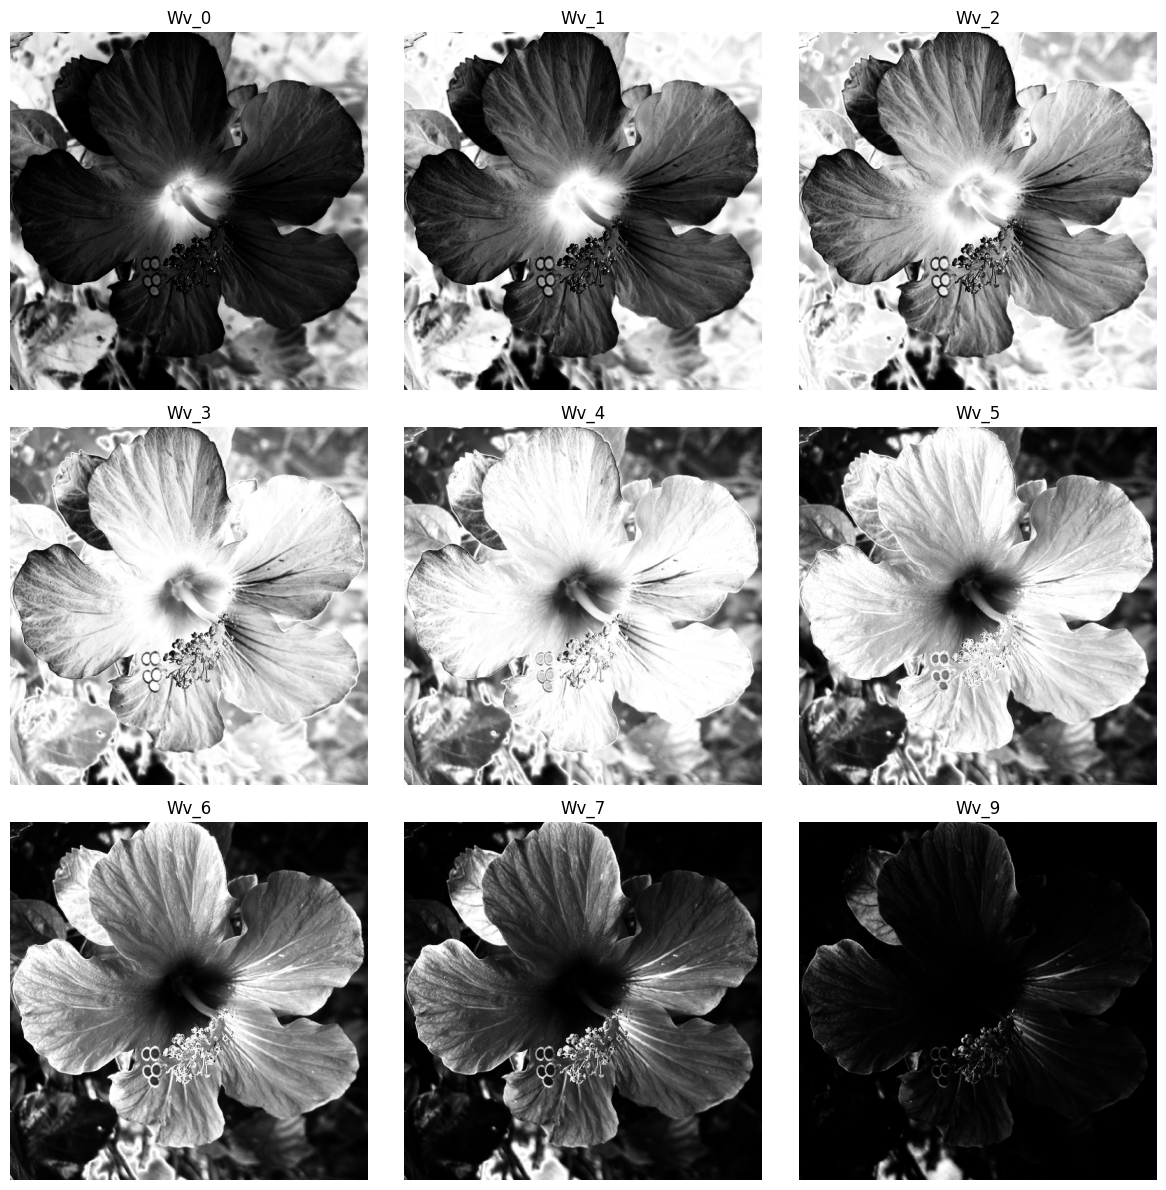

In [30]:
show_weights(W)

Les figures montrent plusieurs cartes de poids $𝑊_{𝑣_𝑖}(𝑥)=𝐺_{\sigma_𝑣}(𝑣_𝑖−𝑓_0(𝑥))$ pour différentes valeurs photométriques de référence $𝑣_𝑖$, uniformément espacées dans [0,1].

Chaque sous‑figure met en évidence les régions de l’image dont l’intensité est proche de $𝑣_𝑖$ : 
- les zones claires correspondent à des pixels fortement pondérés (intensité voisine de $𝑣_i$), 
- alors que les zones sombres indiquent des pixels dont l’intensité est éloignée de $𝑣_i$. 
- ces cartes constituent les couches de la pile de poids utilisée dans l’approximation par empilement.

#### `Raccourci pour le calcul de la pile bilatérale` $\{ F_{v_i} \}_i$

Pour une valeur photométrique de référence $v$, le filtre bilatéral peut s’écrire comme un ratio de convolutions :
$$\mathcal{B}_{\sigma_x,\sigma_v}(f)(x)= \frac{\big[ G_{\sigma_x} * (f \cdot W_v) \big](x)}{\big[ G_{\sigma_x} * W_v \big](x)}$$
 - où la carte de poids est définie par $W_v(x) = G_{\sigma_v}(v - f(x))$

Cette pile sert ensuite à pondérer l'image dans chaque « couche » $v_i$, typiquement pour construire une approximation du filtre bilatéral travaillant dans l’espace $(x,v)$ :

- on choisit un ensemble de valeurs de référence $\{v_i\}_{i=1}^p$
- on construit pour chaque $v_i$ la carte de poids $W_{v_i}(x) = G_{\sigma_v}(v_i - f_0(x))$
- on applique ensuite un flou spatial sur chaque couche puis on reconstruit.

`Concrètement, l’étape suivante consiste à calculer, pour chaque` $i$, `les deux convolutions`

$F_{v_i}(x) = \big(G_{\sigma_x} * (f_0 \cdot W_{v_i})\big)(x), \qquad Z_{v_i}(x) = \big(G_{\sigma_x} * W_{v_i}\big)(x)$

Le rapport $F_{v_i}(x) / Z_{v_i}(x)$ fournit alors, pour chaque couche $v_i$, une estimation locale pondérée de l’image, qui sera ensuite combinée pour approcher le filtre bilatéral complet.

In [218]:
# bileteral_stack_tmp = lambda f0, sx, W: Filter(W.*repmat(f0, [1 1 p]), sx) ./ Filter(W, sx)
import numpy as np
from scipy.ndimage import gaussian_filter

Filter = lambda F, s: np.real(np.fft.ifft2(np.fft.fft2(F) * np.fft.fft2(GaussianFilter(s))))

def gaussian_filter_stack(stack, sx):
    out = np.empty_like(stack)
    for i in range(stack.shape[2]):
#        out[:, :, i] = gaussian_filter(stack[:, :, i], sigma=sx)
        out[:, :, i] = Filter(stack[:, :, i], sx)
    return out

def bileteral_stack(f0, sx, sv, p):
    W = WeightMap(f0, sv, p)           # W  : (n, n, p) 
    f0_stack = f0[:, :, None]          # (n, n, 1) pour broadcasting
    num = gaussian_filter_stack(W * f0_stack, sx)  # Filter(W.*repmat(f0), sx)
    den = gaussian_filter_stack(W, sx) + 1e-7      # Filter(W, sx)
    F = num / den
    return F

Compute the bilateral stack $\{ F_{v_i} \}_i $.

In [101]:
sx = 5
sv = .2
p  = 10

#### __`Exercise 3`__
Affichage de plusieurs tranches de la pile bilatérale  $F_{v_i}$.

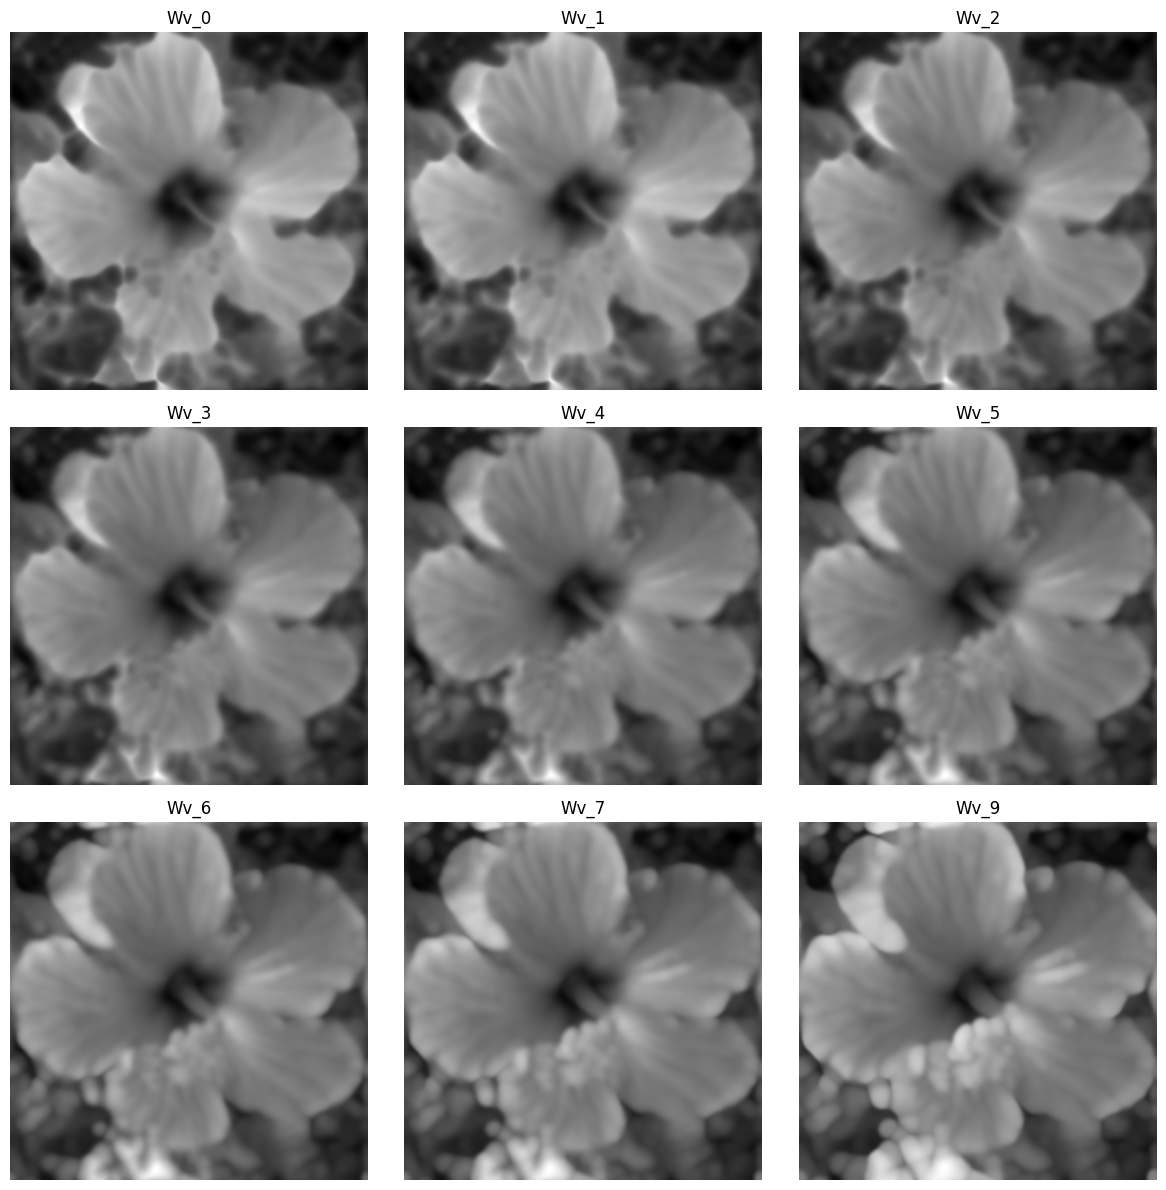

In [102]:
show_weights(clamp(bileteral_stack(f0, sx, sv, p)))

- La figure illustre la pile bilatérale $\{F_{v_i}\}$ obtenue avec $p=10$. 
- les iamges de la sortie filtrée sont associées à une valeur photométrique de référence $v_i$, 
- après pondération par $W_{v_i}$ puis flou gaussien spatial. 
- Ces couches seront ensuite combinées pour approximer le filtre bilatéral complet dans l’espace $(x,v)$.

`Le dé‑empilement consiste à  :` 
 - sélectionner, pour chaque pixel $x$ une couche d’indice $ I(x) \in \{1,\ldots,p\} $
 - on reconstruit alors une image $f_I(x) = F_{ v_{I(x)} }(x)$

La méthode de reconstruction la plus simple consiste à choisir, pour chaque pixel $x$, 
 - la couche dont la valeur $v_i$ est la plus proche de l’intensité 
 - $f(x)$ : $I(x) = \argmin_{ 1 \leq i \leq p } |{f(x)-v_i}|$

Pour le dé‑empilement on adresse les pixels de l’image en ligne/colonne pour faire F[y, x, I], les indices sont:
- $x∈{0,…,n−1}$
- $y∈{0,…,n−1}$

In [96]:
def destacking(F, I):
    n, m, p = F.shape
    assert n == m
    y, x = np.meshgrid(np.arange(n), np.arange(n), indexing='ij')
    return F[y, x, I]

In [84]:
def bilateral_nn(f0, sx, sv, p):
    stack = bileteral_stack(f0, sx, sv, p)   # (n,n,p)
    # indices 0..p-1 des plus proches voisins en valeur
    # Round elements of the array to the nearest integer.
    I = np.rint(f0 * (p-1)).astype(int)
    return destacking(stack, I)

Affichage.

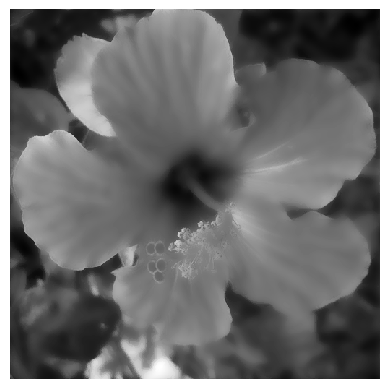

In [100]:
imageplot(clamp(bilateral_nn(f0, sx, sv, p)))

Une meilleure méthode déplillement pour la reconstruction est obtenue par interpolation linéaire de premier ordre.
$$\large \mathcal{B}_{\sigma_x,\sigma_v}(f)(x) \approx (1-\lambda(x))f_{I(x)}(x)  + \lambda(x) f_{I(x)+1}(x)$$

  - où $I(x)$ est l’indice tel que $v_{I(x)}≤f(x)≤v_{I(x)+1}$,
  - et $\lambda(x) \in [0,1]$ est choisi pour que  $f(x) = (1-\lambda(x)) v_{I(x)} + \lambda(x) v_{I(x)+1}$


In [91]:
def frac(x):
    return x - np.floor(x)

def lininterp(f1, f2, Fr):
    return f1 * (1 - Fr) + f2 * Fr

def bilateral_lin(f0, sx, sv, p):
    # F : pile bilatérale (n,n,p)
    F = bileteral_stack(f0, sx, sv, p)
    # coordonnée dans [0,p-1]
    t = f0 * (p - 1)

    # indices entiers 0..p-1 (bornés pour la sécurité)
    I0 = np.floor(t).astype(int)
    I1 = np.ceil(t).astype(int)
    I0 = np.clip(I0, 0, p-1)
    I1 = np.clip(I1, 0, p-1)

    # lambda(x) = partie fractionnaire de t
    lam = t - np.floor(t)

    # destacking 3D : F[y,x,I]
    n, m, _ = F.shape
    y, x = np.meshgrid(np.arange(n), np.arange(m), indexing="ij")
    fI0 = F[y, x, I0]
    fI1 = F[y, x, I1]

    return lininterp(fI0, fI1, lam)

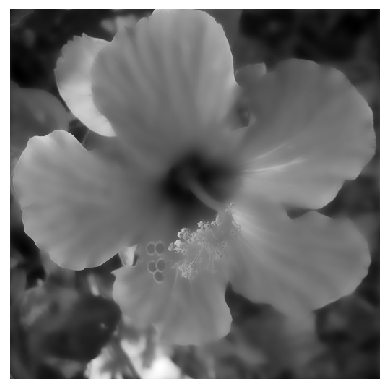

In [99]:
imageplot(clamp(bilateral_lin(f0, sx, sv, p)))

__Exercise 4__

Compare nearest-neighbor and linear destacking.

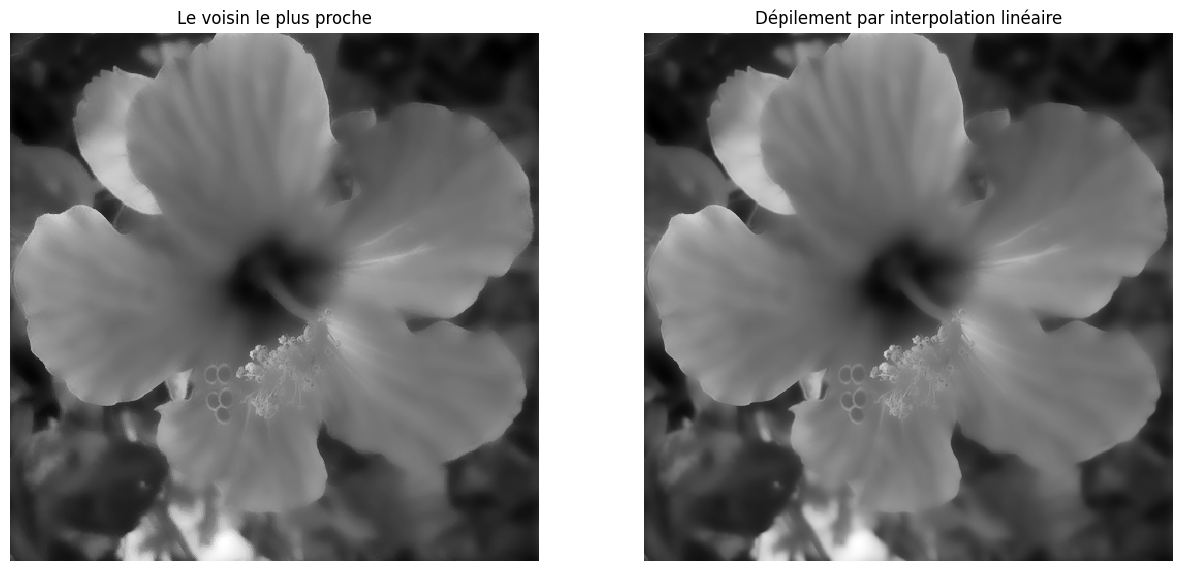

In [98]:
plt.figure(figsize=(15,15))
imageplot(clamp(bilateral_nn(f0, sx, sv, p)),"Le voisin le plus proche",[1,2,1])
imageplot(clamp(bilateral_lin(f0, sx, sv, p)),"Dépilement par interpolation linéaire",[1,2,2])

La figure compare la reconstruction par dé‑empilement au plus proche voisin (gauche) et par interpolation linéaire (droite). 

Visuellement, la version « voisin le plus proche » présente de légères transitions en plateaux dans les zones de dégradés, dues à la quantification en $p$ niveaux photométriques. 

La reconstruction par interpolation linéaire atténue ces artefacts en interpolant entre deux couches successives de la pile $F_{v_i}$, ce qui produit des transitions plus douces tout en conservant le flou bilatéral.

#### __`Exercise 5`__
Visualiser l'influence de $\sigma_x$ pour une valeur fixe de $\sigma_v=0.2$.

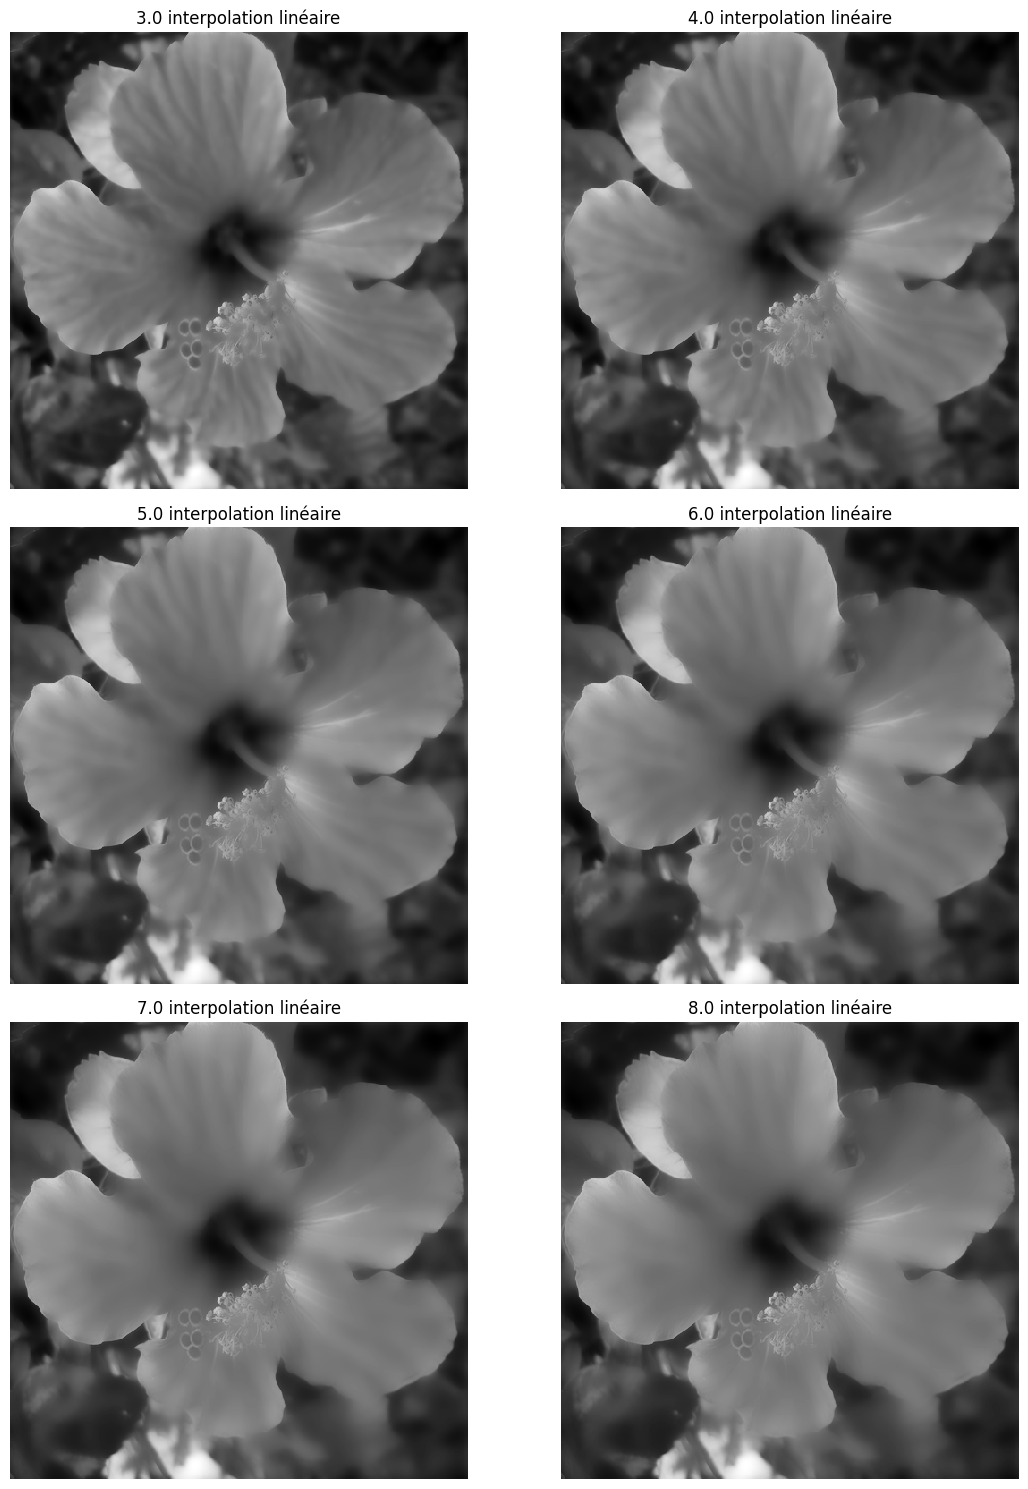

In [135]:
sx_list = np.linspace(3,8,6)
sv = .2
p  = 50
plt.figure(figsize=(12,15))

for i, sx in enumerate(sx_list):
    imageplot(clamp(bilateral_nn(f0, sx, sv, p)),f"{sx} plus proche voisin",[3,2,i+1])
    imageplot(clamp(bilateral_lin(f0, sx, sv, p)),f"{sx} interpolation linéaire",[3,2,i+1])

plt.tight_layout()
plt.show()    

#### __`Exercise 6`__
Visualiser l'influence de $\sigma_v$ sur le filtre bilatéral pour une valeur fixe de $\sigma_x=8$.

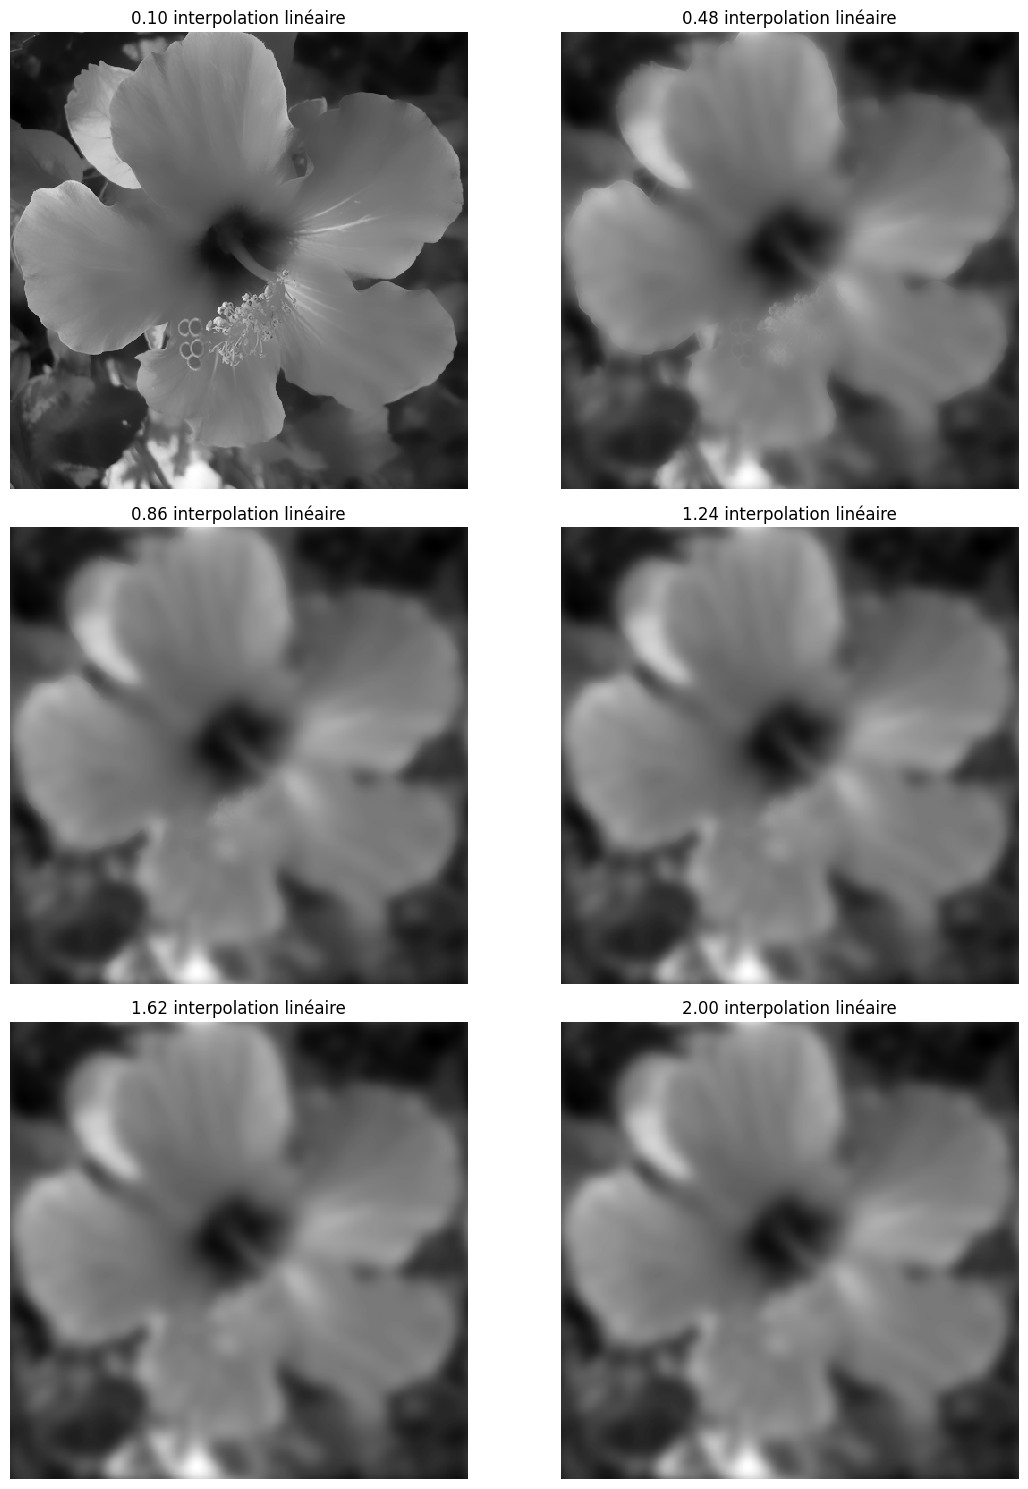

In [136]:
sx_list = 8
sv_list = np.linspace(.1,2,6) 
p  = 50
plt.figure(figsize=(12,15))

for i, sv in enumerate(sv_list):
    imageplot(clamp(bilateral_nn(f0, sx, sv, p)),f"{sv:.2f} plus proche voisin",[3,2,i+1])
    imageplot(clamp(bilateral_lin(f0, sx, sv, p)),f"{sv:.2f} interpolation linéaire",[3,2,i+1])

plt.tight_layout()
plt.show()  

__On note que cette implémentation par empilement du filtre bilatéral peut être assez **approximative**, en particulier lorsque le nombre de niveaux photométriques $p$ est faible.__ 

Une implémentation rapide plus précise est décrite dans :
> _A Fast Approximation of the Bilateral Filter using a Signal Processing Approach_,  
> Sylvain Paris et Frédo Durand,  
> International Journal of Computer Vision (IJCV, 2009).

### __`Dénoyautage (débruitage) avec le filtre bilatéral`__
- La première application élémentaire du filtre bilatéral est le débruitage d’images.  
- Il réalise un lissage qui **respecte les contours**, c’est‑à‑dire qu’il réduit le bruit tout en préservant les discontinuités d’intensité.

Créer une image bruitée $f=f_0+w$ où $w$ est une Gaussienne de bruit blanc avec une variance $\mu^2$. 
Afficher l'image bruitée et débruité utilisant le filtre bilatéral par interpolation linéaire.

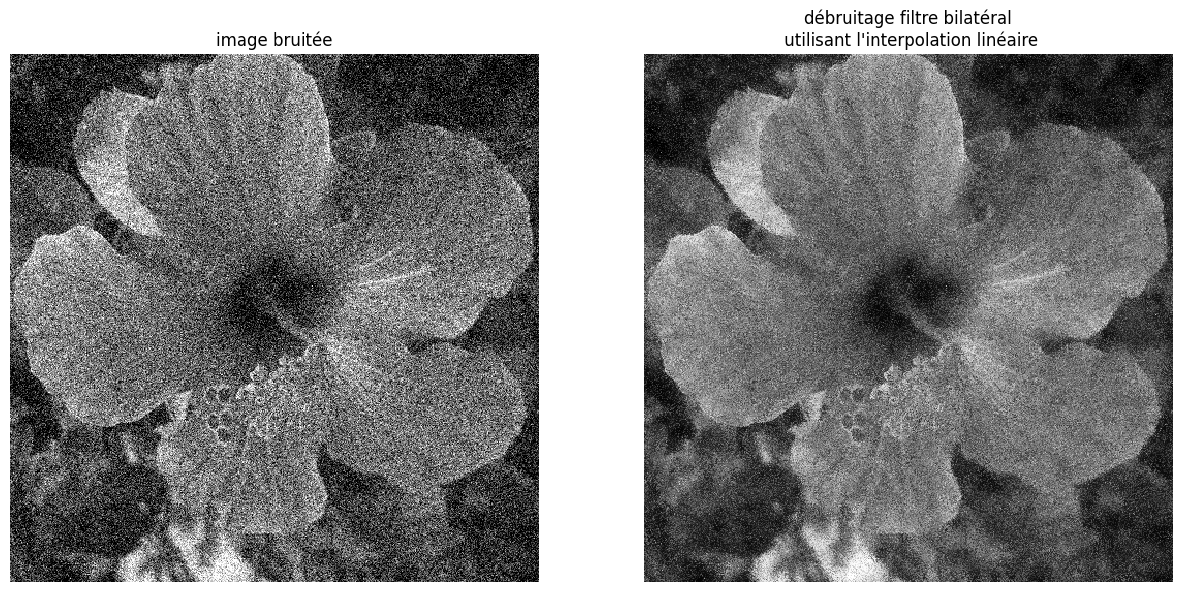

In [208]:
# Niveau de bruit
mu = .2
sx = 4 
sv = .2
p = 10
f = f0 + np.random.randn(n,n)*mu
plt.figure(figsize=(15,15))
imageplot(clamp(f),"image bruitée",[1,2,1])
imageplot(clamp(bilateral_lin(f, sx, sv,p)),"débruitage filtre bilatéral\n utilisant l'interpolation linéaire",[1,2,2])

#### __`Exercise 7`__
Calculer le paramètre optimal $(\sigma_x,\sigma_v)$ pour maximiser le SNR entre $f_0$ et l'image filtrée.

In [215]:
def snr(f0, f_denoise):
    num = np.linalg.norm(f0)             # ||f0||
    den = np.linalg.norm(f0 - f_denoise) # ||f0 - fsob||
    return 20 * np.log10(num/den)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

p  = 50

sv_list = np.linspace(0.02, 0.2, 10)
sx_list = np.linspace(1.5, 6, 10)

plt.figure(figsize=(12,15))

best_snr = -np.inf
best_params = (0,0)
for sv in sv_list:
    for sx in sx_list:
        cur_snr = snr(f, bilateral_lin(f, sx, sv, p))
        if cur_snr > best_snr:
            best_snr = cur_snr
            best_params = (sx, sv)
print(f"{best_params[0]} : {best_params[1]} : {best_params} {best_snr}")
plt.figure(figsize=(15,15))
imageplot(clamp(f),"image bruitée",[1,2,1])
imageplot(clamp(bilateral_lin(f, best_params[0], best_params[1],p)),"débruitage filtre bilatéral\n utilisant l'interpolation linéaire",[1,2,2])
plt.show()

Display optimal denoising.

In [ ]:
imageplot(clamp(fOpt), ['Bilateral, SNR = ' num2str(snr(f0, fOpt), 3) 'dB'])

__Exercise 8__

Compare with translation invariant wavelet thresholding.

In [ ]:
solutions.exo8()

In [ ]:
## Insert your code here.

Detail Enhancement
------------------
The bilateral filters is able to remove fine scale details (noise,
textures) and retain only the cartoon content of the image (shape edges).


Set up parameters $\si_x,\si_v$.

In [ ]:
sx = 4
sv = .2

Performm the filtering to obtain the base layer $ f_1 = \Bb_{\si_x,\si_v}(f_0) $.

In [ ]:
f1 = bilateral_lin(f0, sx, sv)

Compute the detail layer $ r = f_0 - f_1 $.

In [ ]:
r = f0 - f1

Display the base layer.

In [ ]:
imageplot(f1)

Display the residual.

In [ ]:
imageplot(r)

__Exercise 9__

Perform detail boosting by enhancing the detail layer.
For instance use various non-linear remapping of the intensities such as
$ f_1 + \ga r^\al $ for some values of $\ga \geq 1$ and $\al>0$.

In [ ]:
solutions.exo9()

In [ ]:
## Insert your code here.

__Exercise 10__

Extend the bilateral filter for color images.

In [ ]:
solutions.exo10()

In [ ]:
## Insert your code here.

High Dynamic Range Tone Mapping
-------------------------------
Tone mapping corresponds to compressing the contrast of an image that
contains a large dynamic range, in order to be viewable on
a low dynamic range display.


Load a high dynamic range image.

In [ ]:
addpath('toolbox_additional/ ')
name = 'memorial'
f = load_hdr([name '.hdr'])
p = min(size(f, 1), size(f, 2))
f = rescale(f(1: p, 1: p, : ))
f = rescale(clamp(image_resize(f, n, n)))

The pixel values can take very large value and leads to over exposition
(saturation) if displayed with a limited range (clamping of the values).

In [ ]:
imageplot(min(f, 1e-4))

Selecting a higher threshold leads to less saturation but more region
being under exposed (dark).

In [ ]:
imageplot(min(f, 1e-3))

A simple way to process a color image is to perform a change of color
space and to process only the intensity channel.


For instance one can use a HSV color space and process the intensity channel $f_V$.

In [ ]:
fhsv = rgb2hsv(f)
fV = fhsv(: , : , 3)

Shortcut the reconstruct the image using a modified V channel.

In [ ]:
color_recompose = lambda fV: hsv2rgb(cat(3, fhsv(: , : , 1: 2), rescale(fV)))

color_recompose = @(fV1)f.*repmat(fV1./fV, [1 1 3]);


Global tone mapping corresponds to applying a fixed non-linear mapping $\phi$ to
all the pixel to compress the range by displaying $\phi(f_V)$.


A polpular contrast modification is the $\gamma$ correction, that uses
$ \phi(t) = (t+\epsilon)^\al $ for a small $ \epsilon>0 $
and $\al \in (0,1]$.

In [ ]:
epsilon = 1e-5
alpha = 0.1
imageplot(color_recompose((fV + epsilon).^alpha))

__Exercise 11__

Try several tone mapping operators, such as for instance
$$ \phi_1(t)=\frac{t}{t+\epsilon} \qandq \phi_2(t) = \log(t+\epsilon) $$

In [ ]:
solutions.exo11()

In [ ]:
## Insert your code here.

Global tone mapping tends to destroy fine scale details.
A local tone mapping operator decompose the logarithm
$$ F_V = \frac{ \log(f_V + \epsilon)-a }{ b-a } $$
of $f_V$
into a base cartoon layer and a textured layer, and only
compress the base layer. Here $a$ and $b$ are compute to ensure
that $F_V \in [0,1]$.


Compute the rescaled logarithm layer $F_V$.

In [ ]:
epsilon = 1e-5
FV = log(fV + epsilon)
a = min(FV(: )); b = max(FV(: ))
FV = (FV-a)/ (b-a)

The base layer is defined as
$ B_V = \Bb_{\si_x,\si_v}(F_V) $.

In [ ]:
sx = 5; sv = .02
FV1 = bilateral_lin(FV, sx, sv)

The tone mapped intensity image is defined as
$$ \tilde f_V = e^{ ( \ga B_V + F_V - B_V )(b-a)+a  } - \epsilon $$
where $ \ga \in (0,1] $ is the compression factor.
For $\ga=1$, one has $\tilde f_V = f_V$.



Display the filtered layer over the log domain.

In [ ]:
imageplot(FV1)

Display the residual over the log domain.

In [ ]:
imageplot(FV-FV1)

__Exercise 12__

Compute the tone mapped image using $\tilde f_V$.
Test with several value of $\ga,\epsilon, \si_x,\si_v$.

In [ ]:
solutions.exo12()

In [ ]:
## Insert your code here.